<a href="https://colab.research.google.com/github/Hibashanti/Time-Series-Analysis/blob/main/Chicago_Crimes_Core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Chicago Crime Data

- Author : Hiba Shanti

In [20]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt


# Load the Data
- Integrating multiple years of Chicago Crime files into one dataset.  

In [22]:
folder_path = "/content/drive/MyDrive/Axsos Academy/AXSOSACADEMY-1/Time Series Data/Data/Data"
files = os.listdir(folder_path)

print(files)  # to confirm your files

['Chicago-Crime_2001.csv', 'Chicago-Crime_2002.csv', 'Chicago-Crime_2003.csv', 'Chicago-Crime_2004.csv', 'Chicago-Crime_2005.csv', 'Chicago-Crime_2006.csv', 'Chicago-Crime_2007.csv', 'Chicago-Crime_2009.csv', 'Chicago-Crime_2008.csv', 'Chicago-Crime_2010.csv', 'Chicago-Crime_2012.csv', 'Chicago-Crime_2011.csv', 'Chicago-Crime_2013.csv', 'Chicago-Crime_2015.csv', 'Chicago-Crime_2014.csv', 'Chicago-Crime_2016.csv', 'Chicago-Crime_2017.csv', 'Chicago-Crime_2020.csv', 'Chicago-Crime_2019.csv', 'Chicago-Crime_2018.csv', 'Chicago-Crime_2021.csv', 'Chicago-Crime_2022.csv', 'README.txt', 'example_time_series.csv']


In [23]:
df_list = []

for file in files:
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        df_temp = pd.read_csv(file_path)
        df_list.append(df_temp)

# Combine all dataframes
df = pd.concat(df_list, ignore_index=True)

print(df.shape)
df.head()

(7713309, 18)


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,ts_1,ts_2,ts_3,ts_4,ts_5,ts_6
0,1326041.0,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624.0,16.0,NaN,41.957850,-87.749185,NaN,NaN,NaN,NaN,NaN,NaN
1,1319931.0,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825.0,8.0,NaN,41.783892,-87.684841,NaN,NaN,NaN,NaN,NaN,NaN
2,1324743.0,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313.0,3.0,NaN,41.780412,-87.611970,NaN,NaN,NaN,NaN,NaN,NaN
3,1310717.0,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424.0,24.0,NaN,42.012391,-87.678032,NaN,NaN,NaN,NaN,NaN,NaN
4,1318099.0,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214.0,2.0,NaN,41.819538,-87.620020,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# Convert the datt column to a datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='mixed')
df=df.set_index('Date')
df=df.drop(columns="ID")
df.head()

,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,ts_1,ts_2,ts_3,ts_4,ts_5,ts_6
Date,,,,,,,,,,,,,,,,
2001-01-01 01:00:00,BATTERY,SIMPLE,RESIDENCE,False,False,1624.0,16.0,NaN,41.957850,-87.749185,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 13:00:00,BATTERY,SIMPLE,RESIDENCE,False,True,825.0,8.0,NaN,41.783892,-87.684841,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 13:00:00,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313.0,3.0,NaN,41.780412,-87.611970,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 01:00:00,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424.0,24.0,NaN,42.012391,-87.678032,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 01:00:00,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214.0,2.0,NaN,41.819538,-87.620020,NaN,NaN,NaN,NaN,NaN,NaN


## Topic 1) Comparing Police Districts


##### Which district had the most crimes in 2022?


In [6]:
#1- Calculate the number of crimes for each district yearly
crimes=df.groupby("District").resample("YE").size()
crimes

District  Date      
1.0       2001-12-31    14861
          2002-12-31    17974
          2003-12-31    17571
          2004-12-31    17579
          2005-12-31    17700
                        ...  
31.0      2018-12-31       11
          2019-12-31        7
          2020-12-31        4
          2021-12-31       15
          2022-12-31       15
Length: 507, dtype: int64

In [7]:
# 2- Get the crimes for all discrits in 2022
crimes_22=crimes.loc[(slice (None), "2022")]
crimes_22

,0
District,
1.0,13044
2.0,11793
3.0,11937
4.0,13931
5.0,9773
6.0,14694
7.0,10319
8.0,14805
9.0,10376


In [8]:
# Defining Districs with most crimes in 2022
most_crimes_22_number=crimes_22.max()
most_crimes_22_name=crimes_22.idxmax()
print(f"max crime number in 2022 is {most_crimes_22_number},in {most_crimes_22_name} discrit")

max crime number in 2022 is 14805,in 8.0 discrit


#Which District had the least number of crimes?


In [9]:
# Defining Districs with most crimes in 2022

least_crimes_22_number=crimes_22.min()
least_crimes_22_name=crimes_22.idxmin()
print(f"min crime number in 2022 is {least_crimes_22_number},in {least_crimes_22_name} discrit")


min crime number in 2022 is 15,in 31.0 discrit


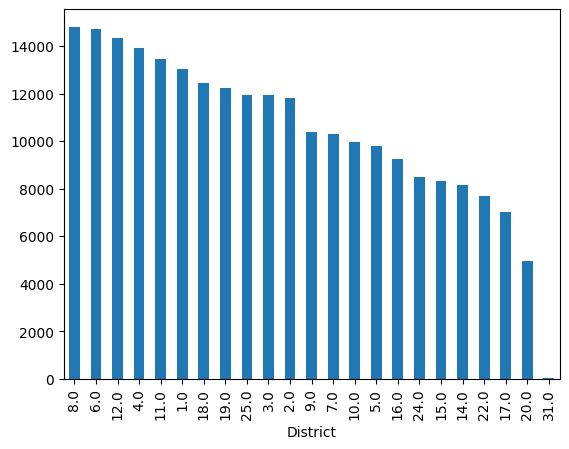

In [10]:
# Visualize the ordered discrits in terms of crime numbers in 2022.
crimes_order=crimes_22.sort_values(ascending=False)
ax=crimes_order.plot(kind="bar")

## Topic 2) Crimes Across the Years:

Text(0, 0.5, 'Number of Crimes')

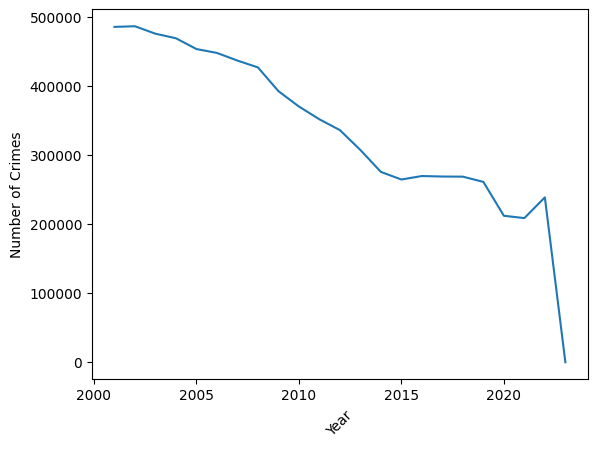

In [26]:
#Is the total number of crimes increasing or decreasing across the years
crimes_trend=df.resample("YE").size()

fig,ax=plt.subplots()
sns.lineplot(x=crimes_trend.index.year, y=crimes_trend.values,ax=ax);
ax.set_xlabel("Year",rotation=45)
ax.set_ylabel("Number of Crimes")


#Chicago crimes have generally decreased over time,with a slight fluctuation.
#The sharp drop in crimes after 2023 is due to incomplete or missing data for the most recent year, not an actual decline.


In [32]:
#Are there any individual crimes that are doing the opposite (e.g., decreasing when overall crime is increasing or vice-versa)?
# 1- define the individual crimes during the years
time_bucket=pd.Grouper(freq="YE")
individual_crimes=df.groupby(["Primary Type", time_bucket]).size()

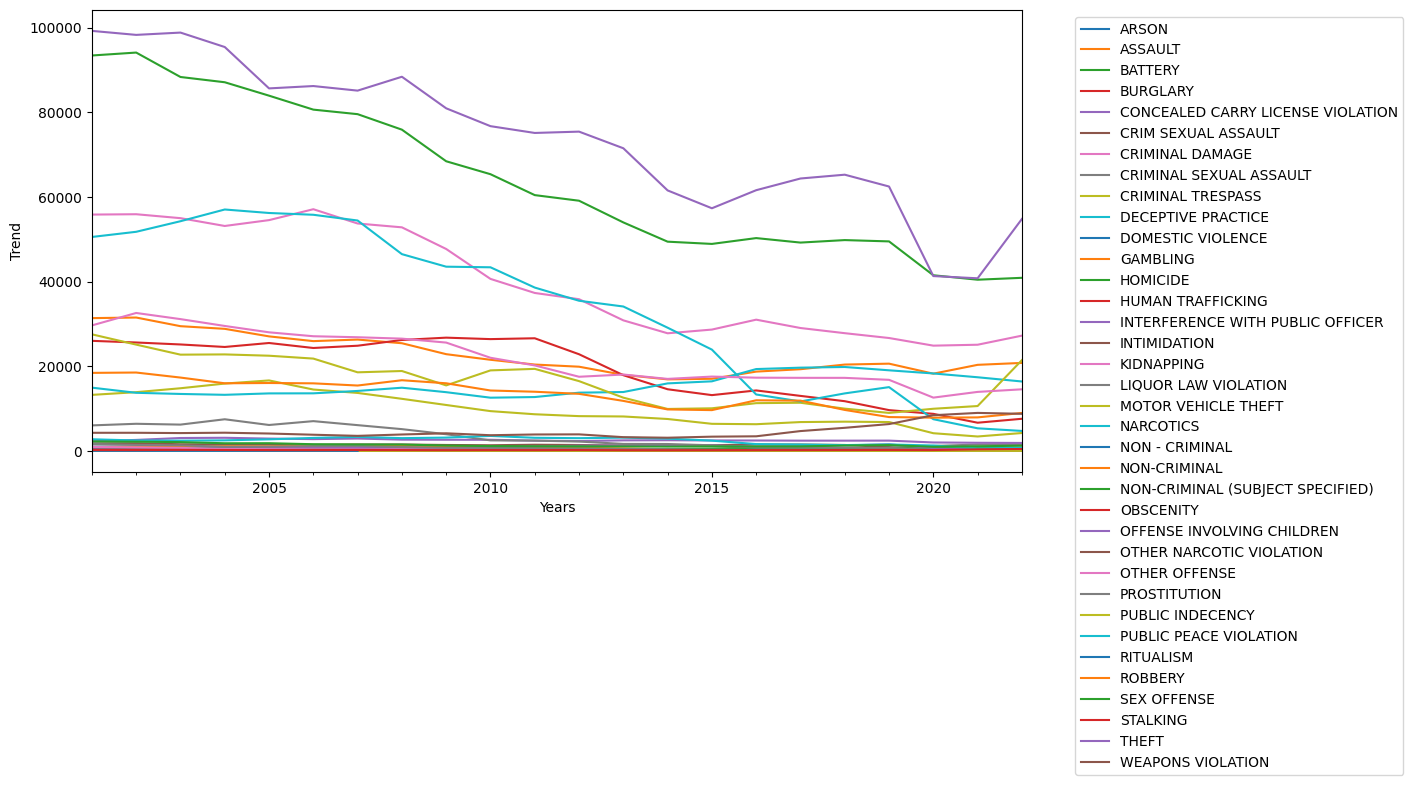

In [49]:
# Visualize the individual crimes during the years
unstacked=individual_crimes.unstack(level=0)
individual_trend=unstacked.plot(figsize=(12,6))
individual_trend.set_xlabel("Years")
individual_trend.set_ylabel("Trend")
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left");


# Topic 3) Comparing AM vs. PM Rush Hour:


- Are crimes more common during AM rush hour or PM rush hour?
  - You can consider any crime that occurred between 7 AM - 10 AM as AM rush hour
  - You can consider any crime that occurred between 4 - 7 PM as PM rush hour.

In [51]:
# 1-Define new column for the Hours in the dataset
df["Hour"]=df.index.hour
df["Hour"]

,Hour
Date,
2001-01-01 01:00:00,1
2001-01-01 13:00:00,13
2001-01-01 13:00:00,13
2001-01-01 01:00:00,1
2001-01-01 01:00:00,1
...,...
2023-10-01 00:00:00,0
2023-10-08 00:00:00,0
2023-10-15 00:00:00,0


In [84]:
# 2-Identify each rushing hour group
am_rush=df[(df["Hour"] >= 7) & (df["Hour"]<= 10)]
pm_rush=df[(df["Hour"] >= 16) & (df["Hour"]<=19)]

In [64]:
# 3-Address the length of each group
am_count=len(am_rush)
pm_count=len(pm_rush)

print(f'The Number of crimes in AM rush hour = {am_count}, and in PM rush hour = {pm_count}')

The Number of crimes in AM rush hour = 1097647, and in PM rush hour = 1641051


- Crimes are more common to occure during PM rush hour with a total number of 1,641,051 compared with a total of 1,097,647 in AM rush hour.


In [71]:
#What are the top 5 most common crimes during AM rush hour? What are the top 5 most common crimes during PM rush hour?
top_5_am=am_rush["Primary Type"].value_counts()
top_5_am.head(5)

,count
Primary Type,
THEFT,260759
BATTERY,158475
CRIMINAL DAMAGE,109089
BURGLARY,96219
OTHER OFFENSE,89870


In [72]:
#What are the top 5 most common crimes during PM rush hour?
top_5_pm=pm_rush["Primary Type"].value_counts()
top_5_pm.head(5)

,count
Primary Type,
THEFT,379122
BATTERY,288003
CRIMINAL DAMAGE,183423
NARCOTICS,164754
ASSAULT,118179


In [87]:
#Are Motor Vehicle Thefts more common during AM rush hour or PM Rush Hour?
# specify the Motor Vehicle Thefts
mvt_am=am_rush[am_rush["Primary Type"]== "MOTOR VEHICLE THEFT"]
mvt_pm=pm_rush[pm_rush["Primary Type"]== "MOTOR VEHICLE THEFT"]

In [88]:
# Define the length of each period
mvt_am_count=len(mvt_am)
mvt_pm_count=len(mvt_pm)
print(f' number of Motor Vehicle Thefts in AM rush hour= {mvt_am_count},number of Motor Vehicle Thefts in PM rush hour= {mvt_pm_count}')

 number of Motor Vehicle Thefts in AM rush hour= 54035,number of Motor Vehicle Thefts in PM rush hour= 74678


- The number of Motor Vehicle Thefts is more common in the PM rush hour.

 # 4) Comparing Months:


In [105]:
# Adding a Month column to the dataset
df["Month"]=df.index.month
df["Month"]

,Month
Date,
2001-01-01 01:00:00,1
2001-01-01 13:00:00,1
2001-01-01 13:00:00,1
2001-01-01 01:00:00,1
2001-01-01 01:00:00,1
...,...
2023-10-01 00:00:00,10
2023-10-08 00:00:00,10
2023-10-15 00:00:00,10


In [110]:
# What months have the most crime? What months have the least?
most_month=df["Month"].max()
least_month=df["Month"].min()
print(f'the months with the most crime is {most_month}, and the month with the least is {least_month} ')

the months with the most crime is 12, and the month with the least is 1 


In [ ]:
#Are there any individual crimes that do not follow this pattern? If so, which crimes?
